In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

from langchain_openai import ChatOpenAI

In [2]:
llm = ChatOpenAI(model="gpt-4o")
llm.invoke("Hello")

AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 8, 'total_tokens': 17, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_f38a9d6fcb', 'id': 'chatcmpl-Dw2btbJyXIkil1GAlhe7bYAZjqM3h', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019f12b7-435a-7693-96f3-b326524d0d83-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 8, 'output_tokens': 9, 'total_tokens': 17, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [3]:
from typing import Annotated, List
import operator
from typing_extensions import TypedDict, Literal
from langgraph.graph import StateGraph,START,END
from IPython.display import Image,display
from pydantic import BaseModel,Field
from langchain_core.messages import HumanMessage,SystemMessage

In [4]:
# Schema for structured output to use in planning
class Section(BaseModel):
    name:str=Field(description="Name for this section of the report")
    description:str=Field(description="Brief overview of the main topics and concepts of the section")

class Sections(BaseModel):
    sections:List[Section]=Field(description="Sections of the report") # Une liste de plusieurs "Section"

# Augment the LLM with schema for structured ouput
planner = llm.with_structured_output(Sections)

# Creating workers dynamically

In [7]:
from langgraph.types import Send # sert à lancer plusieurs exécutions parallèles.

# Graph state
class State(TypedDict):
    topic:str # Report topic
    sections:list[Section] # List of report section
    completed_sections:Annotated[
        list,operator.add
    ] # All workers write to this key in parallel
    final_report:str

# Worker state
class WorkerState(TypedDict):
    section:Section
    completed_sections:Annotated[list,operator.add]
        

In [ ]:
# Nodes

def orchestrator(state:State):
    """Orchestrator that generates a plan for the report"""

    # Generate queries
    report_sections = planner.invoke(
        [
            SystemMessage(content="Generate a plan for the report"),
            HumanMessage(content=f"Here is the report topic: {state['topic']}")
        ]
    )

    print("Report Sections:", report_sections)                 # planner renvoie Sections(sections=[Section(...),Section(...),...])

    return {"sections": report_sections.sections} # Mise à jour du state

def llm_call(state:WorkerState):
    """Worker writes section of the report"""

    # Generate section
    section = llm.invoke(
        [
            SystemMessage(content="Write a report section following the provided name and desciption. Include no preamble for each section"),
            HumanMessage(content=f"Here is the section name: {state['section'].name} and description {state['section'].description}")
        ]
    )

    # Write the updated section to completed sections
    return {"completed_sections" : [section.content]}

# Conditional edge function to create llm_call workers that each write a section of the report

def assign_workers(state:State):
    """Assign a worker to each section in the plan"""

    # Kick off section writing in parallelvia Send() API
    return [Send('llm_call',{"section":s}) for s in state["sections"]]

def synthetizer(state:State):
    """Synthetise full report from sections"""

    # List of completed sections
    completed_sections = state["completed_sections"]

    # Format completed section to str to use as a context for final sections
    completed_report_sections = "\n\n---\n\n".join(completed_sections)

    return {"final_report": completed_report_sections} 

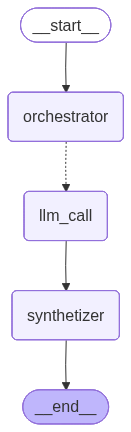

In [13]:
# Build workflow
orchestrator_worker_builder = StateGraph(State)

# Nodes
orchestrator_worker_builder.add_node("orchestrator",orchestrator)
orchestrator_worker_builder.add_node("llm_call",llm_call)
orchestrator_worker_builder.add_node("synthetizer",synthetizer)

# Edges
orchestrator_worker_builder.add_edge(START,"orchestrator")
orchestrator_worker_builder.add_conditional_edges("orchestrator",assign_workers, ["llm_call"])
orchestrator_worker_builder.add_edge("llm_call","synthetizer")
orchestrator_worker_builder.add_edge("synthetizer",END)

# Compile workflow
orchestrator_worker = orchestrator_worker_builder.compile()

# Visualize the graph
display(Image(orchestrator_worker.get_graph().draw_mermaid_png()))


In [14]:
state = orchestrator_worker.invoke({"topic" : "Create a report on Agentic AI RAGs"})

from IPython.display import Markdown
Markdown(state["final_report"])

Report Sections: sections=[Section(name='Introduction to Agentic AI and RAGs', description='This section will provide a foundational understanding of what Agentic AI and RAGs (Random Access Generators) are. It will briefly describe the significance of RAGs in the context of artificial intelligence and provide an overview of the history of Agentic AI development.'), Section(name='Core Concepts and Definitions', description='This section will delve into the technical definitions and core concepts underpinning Agentic AI and RAGs. It will cover key terminologies, theoretical frameworks, and the principles guiding the design and functioning of these AI systems.'), Section(name='Applications of Agentic AI RAGs', description='This section will explore real-world applications of Agentic AI RAGs. It will discuss how they are currently being implemented across different industries, such as healthcare, finance, or entertainment, and highlight case studies showcasing their impact and potential.')

The realm of artificial intelligence (AI) is constantly evolving, with new concepts and technologies emerging to address complex challenges. Among these advancements are Agentic AI and Random Access Generators (RAGs), each playing a pivotal role in shaping the future of intelligent systems. Providing a foundational understanding of these components is essential in appreciating their transformative potential.

Agentic AI refers to artificial intelligence systems designed to operate with a level of autonomy and agency reminiscent of living beings. These systems are not only capable of executing predefined tasks but also possess the ability to make independent decisions, adapt to new environments, and interact intelligently with both humans and other AI systems. The development of Agentic AI is driven by the pursuit of creating systems that can perform tasks with minimal human intervention, thereby increasing efficiency and the range of applications for AI technologies.

Significantly contributing to the capabilities of Agentic AI are Random Access Generators (RAGs), which are crucial in generating random or pseudo-random data inputs that enable the AI system to operate under varying conditions and scenarios. RAGs facilitate the diversification of responses and learning experiences for AI, enhancing its adaptability and robustness. The use of RAGs ensures that AI systems do not rely solely on static datasets or predictable inputs, thus fostering a more dynamic and flexible approach to problem-solving.

The history of Agentic AI development traces back to the early days of AI research, where the focus was largely on rule-based systems. These early models were constrained by their narrow scope and lack of adaptability. As computing power and algorithms advanced, the vision for AI systems evolved to encompass more complex, adaptive models capable of autonomous behavior — a journey marked by incremental breakthroughs in neural networks, machine learning, and deep learning methodologies. The introduction of Agentic AI signifies a paradigm shift, as it embodies the integration of cognitive architectures designed to simulate human-like decision-making processes with the engineering of systems capable of self-regulation and self-improvement.

In essence, understanding Agentic AI and RAGs entails recognizing the intersection of autonomy, adaptability, and randomization in AI systems. These components are shaping the trajectory of AI towards more sophisticated, resilient, and human-interactive systems. As we continue to advance in this domain, the collaborative synergy between Agentic AI and RAGs is poised to unlock new possibilities across industries, ultimately redefining the capabilities and applications of artificial intelligence in our daily lives.

---

### Core Concepts and Definitions

Agentic AI represents a paradigm shift in artificial intelligence, emphasizing autonomy, decision-making capabilities, and interactive engagements akin to those of an independent agent. Key to understanding Agentic AI are several technical definitions and foundational concepts that frame its functioning and application in modern systems.

**Autonomy and Agency:** At the heart of Agentic AI is the principle of autonomy, which refers to an AI system's ability to operate independently of human intervention. Autonomy in AI is facilitated by algorithms and decision-making frameworks that allow the agent to perform tasks, make decisions, and adapt to new information or changing environments. Agency, while closely related, extends to the AI’s capacity to engage, learn, and execute actions in pursuit of defined goals, often in complex and dynamic settings.

**Reinforcement Learning:** This learning framework supports the development of Agentic AI by enabling systems to learn optimal behaviors through interactions with their environment. Reinforcement learning involves using rewards and punishments as feedback for the AI to develop strategies that maximize performance or desired outcomes based on a predefined reward system.

**Interactive and Adaptive Systems:** Agentic AI systems are designed to be interactive, meaning they can engage in two-way communications with humans or other AI systems. They are also adaptive, allowing them to modify their actions in response to new data or shifting circumstances. This adaptability is crucial for maintaining performance in volatile environments.

**RAGs (Retrieval-Augmented Generation):** RAGs enhance traditional AI generation models by incorporating retrieval mechanisms. This process dynamically pulls relevant data from large datasets or databases, integrating contextual information into the generated outputs. The synergy between retrieval and generation leads to more accurate, contextually aware results, making RAGs particularly valuable in fields requiring the synthesis of up-to-date and specialized knowledge.

**Hybrid AI Models:** RAGs represent a form of hybrid AI, where retrieval mechanisms leverage structured data sources to inform generation models. Hybrid models capitalize on the strengths of different AI approaches, achieving greater efficacy and versatility. The hybrid nature of RAGs ensures that AI outputs reflect the most current and context-specific data available, thereby enhancing decision-making processes and the generation of insights.

**Theoretical Frameworks:** Agentic AI and RAG systems are underpinned by theoretical frameworks that dictate their design and operation. These frameworks draw from multiple disciplines, including cognitive science, computational biology, and systems theory, emphasizing concepts such as emergent behaviors, self-organization, and complex adaptive systems. They guide the development of AI architectures that are not only technically robust but also capable of replicating the nuanced decision-making and interactive capabilities traditionally attributed to human agency.

**Ethical and Functional Design:** The principles guiding the design of Agentic AI systems focus on ethical considerations and transparency. It is imperative for these systems to operate within ethical boundaries, respecting privacy, fairness, and user safety. Furthermore, the systems must be transparent in their operations, fostering trust through clear and understandable decision-making processes.

In conclusion, the core concepts and definitions of Agentic AI and RAGs highlight the interplay between autonomy, interactivity, and the integration of retrieval mechanisms in AI systems. These principles and frameworks not only define the technological landscape of AI development but also set the stage for future innovations in intelligent and autonomous system design.

---

Applications of Agentic AI RAGs

Agentic AI Recurrent Adventure Generators (RAGs) are swiftly becoming prominent in various sectors, offering innovative solutions that transform conventional processes into more dynamic and adaptive systems. By integrating self-learning and decision-making capabilities, these advanced models are being leveraged to drive efficiencies, enhance user experience, and create new opportunities across multiple industries. Below, we explore several real-world applications of Agentic AI RAGs, demonstrating their current implementation, accompanied by case studies that highlight their significant impact and potential.

1. Healthcare: 

In healthcare, Agentic AI RAGs are revolutionizing patient care and operational management. They can simulate various patient scenarios, allowing healthcare providers to predict outcomes and tailor personalized treatment plans more accurately. For instance, a progressive hospital network has deployed RAGs to optimize surgical scheduling, leading to a 25% improvement in hospital throughput. A case study highlights how implementing RAGs in chronic disease management helps to refine medication regimens for individual patients by dynamically altering drug recommendations based on real-time health data and patient feedback.

2. Finance:

The finance industry has widely embraced Agentic AI RAGs to enhance decision-making processes and risk assessment. These systems can process vast datasets to identify trends and make real-time trading decisions with minimal human intervention. In a notable application, a leading investment firm uses RAGs to develop predictive models that anticipate market shifts, significantly boosting their portfolio performance. Furthermore, RAGs are employed in fraud detection, where they dynamically adapt to evolving fraudulent schemes, thereby minimizing financial losses for banks and customers.

3. Entertainment:

In the realm of entertainment, particularly gaming and content creation, Agentic AI RAGs offer new possibilities for engaging and immersive experiences. The use of RAGs allows for the generation of complex storylines and character interactions that adapt to players' choices, significantly enhancing the gaming experience. A celebrated game development company implemented RAGs in their latest online role-playing game, allowing for unique story arcs and digital environments that evolve with player actions, thus increasing player retention and satisfaction.

4. Marketing and Advertising:

Agentic AI RAGs are transforming marketing strategies by offering personalized advertising content that adjusts to consumer behavior in real-time. A major retailer utilized RAGs to create dynamic marketing campaigns that tailor promotions and product recommendations based on customer interactions and preferences. This approach has yielded a 30% increase in click-through rates and substantial revenue growth. Case studies reveal the potential of RAGs in predictive analysis, allowing marketers to foresee consumer trends and adjust strategies promptly, ensuring they remain competitive.

5. Logistics and Supply Chain:

Agentic AI RAGs enhance the logistics and supply chain domain by optimizing routing schedules and inventory management. A logistics firm implemented RAGs to simulate various delivery scenarios, improving the efficiency of their distribution network. This resulted in a 20% reduction in delivery times and operational costs. Additionally, RAGs facilitate better demand forecasting and inventory control, enabling companies to maintain optimal stock levels and minimize wastage.

In conclusion, the applications of Agentic AI RAGs across diverse industries highlight their disruptive potential and adaptability. By fostering innovation, these systems are expected to continue redefining operational capabilities and consumer engagement strategies in the near future, signifying a substantial shift towards more intelligent and autonomous systems across all sectors.

---

The development and deployment of Agentic AI Retrieval-Augmented Generative Systems (RAGs) present a set of technical challenges that need thorough exploration and effective solutions. Below is an analysis of these challenges and the innovative strategies being adopted to address them.

### Scalability
**Challenge**: As RAGs are integrated into large-scale systems, they face significant hurdles in scaling to accommodate increasing amounts of data and diverse query demands. The necessity to manage high-throughput requests while maintaining low-latency responses is a primary concern, particularly for deployment in real-time applications.

**Solutions**: Recent advancements in distributed computing frameworks and parallel processing technologies are being leveraged to enhance scalability. Techniques such as load balancing, microservices architecture, and the use of efficient indexing systems are under active research to ensure that RAGs can handle growing data influx without compromising performance.

### Data Integration and Quality
**Challenge**: Integrating heterogeneous data sources into a coherent RAG system is complex and can lead to issues with data consistency and quality. Inaccurate data integration can result in misleading outputs from AI models.

**Solutions**: Implementing sophisticated data fusion algorithms that are capable of harmonizing data from various sources is a key strategy. Enhanced data validation protocols and the employment of AI-based data cleansing tools are essential to maintaining data integrity and consistency, ensuring the reliable performance of RAGs.

### Model Interpretability and Trust
**Challenge**: RAGs, by their nature, are complex models which often operate as opaque "black boxes," leading to difficulties in understanding and trusting their outputs. This is a hurdle in fields that require transparency for decision-making processes.

**Solutions**: Enhancing model interpretability through techniques like attention visualization and explainable AI (XAI) methods is currently being pursued. Developing user-friendly interfaces that allow for model query interaction and result tracking is seen as a promising way to build user trust and facilitate acceptance.

### Computational Efficiency
**Challenge**: RAG systems demand substantial computational resources due to their intricate architectures, which can make them costly to operate, particularly at scale.

**Solutions**: Strategies for boosting computational efficiency include model pruning and quantization, which reduce model size and complexity without sacrificing accuracy. Additionally, optimizing algorithmic workflows and leveraging cloud-based solutions that provide dynamic computing resources are proving effective to manage and reduce operational costs.

### Privacy and Security
**Challenge**: Ensuring data privacy and securing vast amounts of sensitive information handled by RAGs is a critical concern, especially in sectors like healthcare and finance, where confidentiality is paramount.

**Solutions**: Implementing robust encryption methods and secure data handling protocols are foundational strategies. Federated learning, which allows models to learn from decentralized data sources without direct data exchange, is an innovative approach gaining traction to uphold privacy standards.

### Knowledge Obsolescence
**Challenge**: The rapid pace of information change can lead RAG systems to possess outdated knowledge, affecting their reliability and accuracy in providing up-to-date information.

**Solutions**: Continuous learning mechanisms and regular model updates are being integrated to ensure that RAGs remain abreast of the latest information. These include techniques like online learning and automated data scraping from trusted sources to perpetually refresh the model’s knowledge base.

By addressing these challenges with innovative and evolving solutions, the deployment of RAGs can achieve higher efficiency, reliability, and user acceptance, paving the way for their expanded application across various domains.

---

The advancement of Agentic AI Retrieval-Augmented Generative Systems (RAGs) brings a spectrum of ethical and societal considerations that require thorough examination. As these systems become more integrated into daily life, addressing their potential impact on privacy, security, decision-making, and the possibility of misuse is paramount.

**Privacy Concerns**: One of the foremost ethical issues surrounding Agentic AI RAGs is the potential invasion of privacy. These systems often rely on collecting and processing vast amounts of data to function effectively. The sheer volume of data necessitates robust safeguards to protect personal information from unauthorized access or misuse. Additionally, the opaque nature of AI's decision-making processes can make it challenging for individuals to understand how their data is being used or to provide informed consent. Ensuring that AI systems respect user privacy and comply with data protection regulations like GDPR is essential to maintaining public trust.

**Security Implications**: The integration of Agentic AI into critical infrastructure poses significant security challenges. As these systems become targets for malicious attacks, it is crucial to implement stringent security measures to prevent unauthorized access and exploitation. The potential for AI systems to be weaponized or used in cyber warfare adds another layer of complexity. Continuous monitoring and updating of AI security protocols are necessary to mitigate these risks and protect sensitive information from breaches.

**Decision-Making and Accountability**: The delegation of decision-making to AI systems raises questions about accountability and transparency. In scenarios where AI is used to make decisions that significantly impact human lives, such as in healthcare or criminal justice, it is essential to retain human oversight to ensure fairness and avoid biases. The challenge lies in balancing the efficiency of AI with the necessity of human intervention, especially when decisions are complex and nuanced. Establishing clear guidelines and frameworks for decision-making can help address these ethical concerns.

**Potential for Misuse**: Despite their capabilities, the potential misuse of Agentic AI RAGs presents a daunting ethical dilemma. These systems could be exploited to create false narratives, generate misleading information, or even manipulate public opinion. The development of deepfakes and AI-generated content that resembles reality poses a significant threat to societal trust in information. Implementing measures to detect and counteract such misuse is crucial to preserving the integrity of information and preventing the erosion of trust in digital media.

**Unintended Consequences**: The deployment of Agentic AI RAGs might lead to unintended societal consequences. For example, the automation of tasks previously done by humans can result in significant shifts in employment patterns and economic structures. Additionally, the dependency on AI systems could impact human cognitive skills and decision-making capabilities. It is essential to forecast these outcomes and develop strategies to counteract negative impacts on society.

In conclusion, while Agentic AI RAGs offer numerous benefits, their ethical and societal implications must not be overlooked. Ensuring these systems are aligned with societal values and human rights will be essential to their successful integration. Policymakers and technologists must collaborate to establish ethical guidelines, regulatory frameworks, and robust safeguards to mitigate the risks associated with these advanced AI systems.

---

Future Prospects and Innovations 

As the field of Artificial Intelligence continues to advance, the role of Agentic AI and Resource Allocation Games (RAGs) is becoming increasingly significant in driving innovation and enhancing decision-making processes. The future prospects of Agentic AI and RAGs are poised to bring transformative changes across various sectors, from healthcare and finance to logistics and entertainment.

Emerging Technologies

One of the most promising avenues in this domain is the integration of Agentic AI with blockchain technology. This combination could enhance the transparency, autonomy, and security of AI systems, offering decentralized solutions for complex resource allocation challenges. Blockchain-enabled smart contracts can facilitate more efficient and secure transactions, ensuring fair resource distribution in RAGs without the need for central authority.

Another exciting development is the advancement in quantum computing, which holds the potential to revolutionize RAGs by optimizing resource allocation problems that are currently intractable with classical computing. Quantum algorithms can process vast amounts of information at unprecedented speeds, enabling AI agents to evaluate numerous scenarios and make superior decisions in real time.

Ongoing Research

Current research is focused on improving the adaptability and learning capabilities of AI agents. By developing more sophisticated learning models that incorporate elements of deep learning and reinforcement learning, researchers aim to create AI agents capable of understanding complex environments and making data-driven decisions that optimize outcomes.

Additionally, there is a growing interest in the development of ethical frameworks and value alignment strategies to ensure that Agentic AI systems operate within ethical boundaries and align with human values. These frameworks are crucial to addressing the potential risks and unintended consequences associated with increasingly autonomous AI systems.

Potential Advancements

The future of Agentic AI and RAGs may see the emergence of highly personalized AI agents that can assist individuals and businesses by understanding preferences, predicting needs, and facilitating optimal resource allocation. This personalization could extend into healthcare, where AI agents might tailor treatment plans to individual patients, or in education, where they could customize learning experiences to enhance student outcomes.

Moreover, we anticipate significant advancements in multi-agent systems, where diverse AI agents collaborate and compete within complex environments. Such systems could simulate and solve large-scale resource allocation problems more effectively, leading to innovations in smart city planning, sustainable energy distribution, and disaster response strategies.

In conclusion, the future prospects of Agentic AI and RAGs are vast and filled with potential. As emerging technologies and ongoing research continue to push the boundaries of what is possible, we can expect to see innovations that not only optimize resource allocation but also fundamentally enhance the capabilities of AI agents, transforming how we approach decision-making in an increasingly connected world.

---

The analysis within this report underscores the significance of adapting to rapid industry changes driven by technological advancements, shifting market demands, and regulatory landscapes. Key points discussed include the transformative power of innovative technologies, the growing emphasis on sustainability, and the challenges posed by global market volatility.

In light of these findings, the following recommendations are proposed:

1. **For Industry Stakeholders**:
   - **Embrace Innovation**: Companies should actively invest in research and development to incorporate emerging technologies such as AI, blockchain, and data analytics to enhance operational efficiency and product offerings.
   - **Sustainability Practices**: Developing robust sustainability frameworks is imperative. Stakeholders should prioritize eco-friendly processes and product lifecycle management to meet consumer demand and regulatory requirements.
   - **Agility in Strategy**: Companies must cultivate organizational agility to swiftly respond to market changes, thus maintaining competitiveness in a globalized economy.

2. **For Policymakers**:
   - **Supportive Legislation**: Policymaker initiatives should aim at creating an environment conducive to innovation by streamlining regulations and offering incentives for sustainable practices and technological adoption.
   - **Global Collaboration**: Engaging in international cooperation to establish standardized regulatory practices can help mitigate cross-border challenges and support seamless global trade.

3. **For Researchers**:
   - **Interdisciplinary Approaches**: Researchers should pursue interdisciplinary studies that intersect technology, economics, and environmental sciences to provide holistic insights into industry advancements.
   - **Focus on Emerging Markets**: Greater research emphasis is necessary on understanding the unique dynamics of emerging markets, which present untapped opportunities for growth and innovation.
   - **Longitudinal Studies**: There's a need to conduct longitudinal studies that track industry changes over time, offering valuable foresight into trends and their impact on various sectors.

Overall, a collaborative effort across all stakeholders will be paramount to navigate the complexities highlighted in this report. By fostering innovation, embracing sustainable practices, and fostering policy coherence, the industry can capitalize on opportunities and address challenges effectively. Further research in highlighted areas will enhance the understanding and strategic response to evolving industry landscapes.